- Importing the required *Libraries*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, random, glob
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
base_dir = "/content/drive/MyDrive/chest_xray"

- counting the number of NORMAL and PNEUMONIA Images in Train,Val,Test

TRAIN -> NORMAL: 1342, PNEUMONIA: 3890


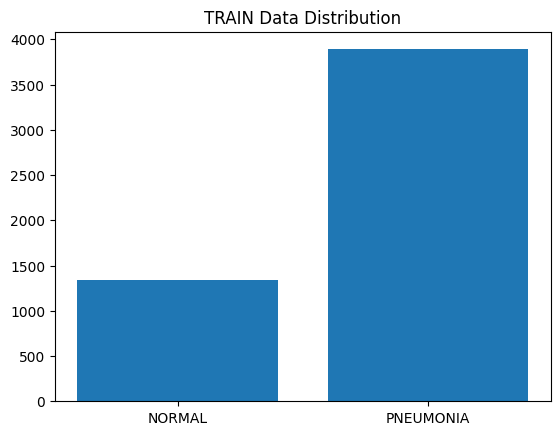

VAL -> NORMAL: 9, PNEUMONIA: 9


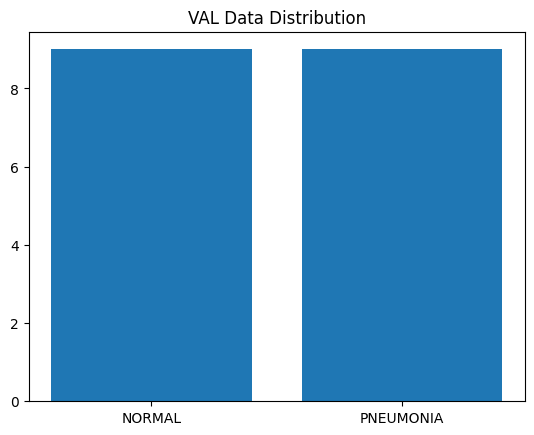

TEST -> NORMAL: 234, PNEUMONIA: 390


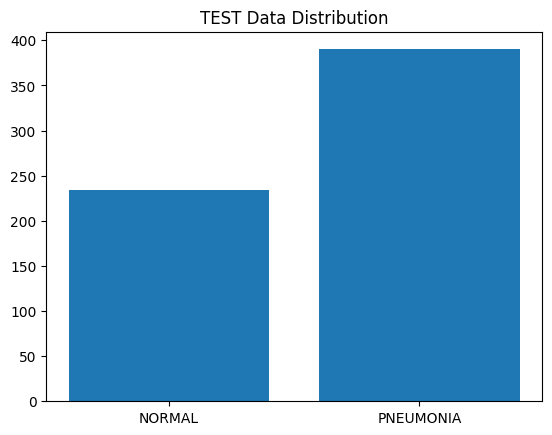

In [ ]:
for subset in ['train', 'val', 'test']:
    normal = len(os.listdir(os.path.join(base_dir, subset, 'NORMAL')))
    pneu   = len(os.listdir(os.path.join(base_dir, subset, 'PNEUMONIA')))
    print(f"{subset.upper()} -> NORMAL: {normal}, PNEUMONIA: {pneu}")
    plt.bar(['NORMAL', 'PNEUMONIA'], [normal, pneu])
    plt.title(f"{subset.upper()} Data Distribution")
    plt.show()

In [ ]:
sizes = []
for path in random.sample(glob.glob(f"{base_dir}/train/NORMAL/*"), 5):
    img = Image.open(path)
    sizes.append(img.size)

In [ ]:
sizes

[(1188, 885), (1804, 1612), (1586, 1217), (1524, 1410), (1422, 1066)]

- as we have different sizes for different images we use the resizing of the images . and for RESNET we needed to give Input Image size 224X224

In [ ]:
normal_paths = glob.glob(f"{base_dir}/train/NORMAL/*")
pneu_paths   = glob.glob(f"{base_dir}/train/PNEUMONIA/*")

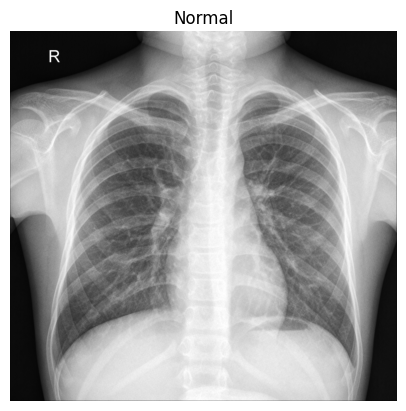

In [ ]:
import random
plt.axis('off')
plt.imshow(
    tf.keras.preprocessing.image.load_img(random.choice(normal_paths))
)
plt.title('Normal')
plt.show()

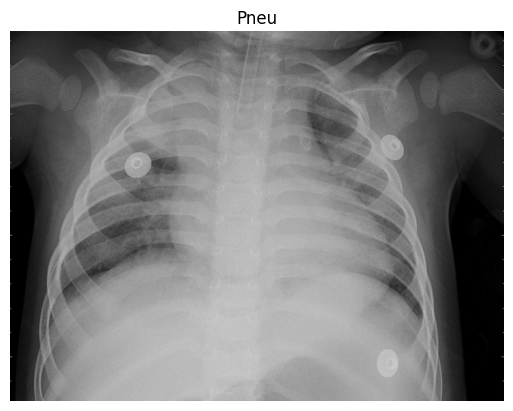

In [ ]:
import random
plt.axis('off')
plt.imshow(
    tf.keras.preprocessing.image.load_img(random.choice(pneu_paths))
)
plt.title('Pneu')
plt.show()

- new images are generated as the dataset size is less, we made new images from existing images using the "ImageDataGenerator" by rotating,flipping , including the normalizing => which helps to reach the Min Loss Fast

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 4185 images belonging to 2 classes.


In [ ]:
val_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1045 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


- we gave the batch size 32 => so eacch train_gen and val_gen have the batch size 32 => 32 labels/iamges for each epoch during training .
- each epoch=> 131 => 131*32=4192 approximately 4187 trainabel images . actual train_dataset images = 5232 => 0.2 for validation so 5232-1046 = 4186 total images for training

In [ ]:
images, labels = next(train_gen)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 1. 0. 1. 1. 1. 1. 0.]


In [ ]:
print(train_gen.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


# Using the CNN Architecture => without pretrained model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

- Using a simple CNN Architecture to see the accuracy ...

In [ ]:
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2735s 21s/step - accuracy: 0.8664 - loss: 0.4470 - val_accuracy: 0.7435 - val_loss: 3.5793
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 874ms/step - accuracy: 0.9323 - loss: 0.1634 - val_accuracy: 0.7435 - val_loss: 5.4681
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 878ms/step - accuracy: 0.9434 - loss: 0.1384 - val_accuracy: 0.7435 - val_loss: 2.6583
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 872ms/step - accuracy: 0.9580 - loss: 0.1241 - val_accuracy: 0.7722 - val_loss: 1.1585
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 879ms/step - accuracy: 0.9592 - loss: 0.1145 - val_accuracy: 0.9263 - val_loss: 0.1827
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 883ms/step - accuracy: 0.9604 - loss: 0.1060 - val_accuracy: 0.9541 - val_loss: 0.1142
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 876ms/step - accuracy: 0.9576 - loss: 0.1036 - val_accuracy: 0.9522 - val_loss: 0.1371
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 884ms/step - accuracy: 0.9641 - 

In [ ]:
history_cnn.history

{'accuracy': [0.9118279814720154,
  0.9383512735366821,
  0.9459975957870483,
  0.9555555582046509,
  0.9589008092880249,
  0.9596176743507385,
  0.9591397643089294,
  0.9632019400596619,
  0.9701313972473145,
  0.968697726726532],
 'loss': [0.27628904581069946,
  0.1591535210609436,
  0.13788948953151703,
  0.11995537579059601,
  0.11577364057302475,
  0.11090276390314102,
  0.09980256110429764,
  0.09990528970956802,
  0.08667837828397751,
  0.08693244308233261],
 'val_accuracy': [0.7435406446456909,
  0.7435406446456909,
  0.7435406446456909,
  0.7722488045692444,
  0.9263157844543457,
  0.9540669918060303,
  0.9521530866622925,
  0.9301435351371765,
  0.9052631855010986,
  0.9626794457435608],
 'val_loss': [3.5792529582977295,
  5.468109607696533,
  2.6583118438720703,
  1.1584572792053223,
  0.18267475068569183,
  0.11416801065206528,
  0.13710229098796844,
  0.17347754538059235,
  0.22982603311538696,
  0.09607543051242828]}

In [ ]:
cnn_model.save("/content/drive/MyDrive/chest_models/chest_CNN.keras")

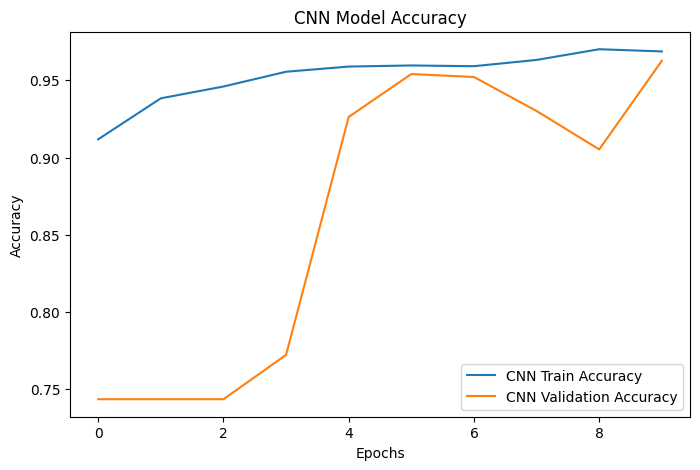

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


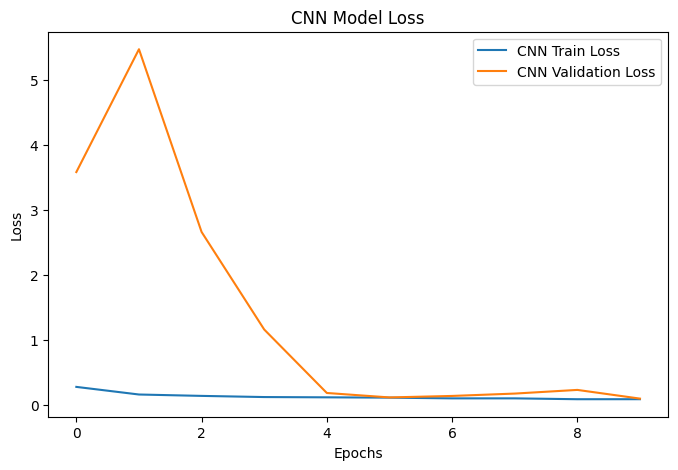

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='CNN Train Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# **Using the "ResNet50" PreTrained Model**



In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- leaving the inner layers Trainable parameters not to train again during the training

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

- removing o/p layer of the pretrained model , adding the PoolingLayer , Dense Layer and DropOut Layer

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

- Using the dropout so that the bias towards a particular feature wont occurs => means giving importance to only some features wont occur => reduces the overfitting which we can seen in the Pretrained model if we use as it is on small dataset
- removes some weights and so it can give preference to other parameters also

- used "GlobalAveragePooling2D" instead of Flattening because the ResNet layer we get have many dimesions so flattening it and sending it to Dense Layers is difficult while training . so used the "GlobalAveragePooling2D" which reduces the dimension
- They are trained for transfer learning on huge datasets (like ImageNet)
- GAP makes them more robust to spatial translation
- They reduce parameters → smaller memory, better generalization

- as binary classification problem

In [ ]:
output = Dense(1, activation='sigmoid')(x)

In [ ]:
model_ResNet = Model(inputs=base_model.input, outputs=output)
model_ResNet.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_ResNet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_ResNet = model_ResNet.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 143s 988ms/step - accuracy: 0.6946 - loss: 0.6185 - val_accuracy: 0.7435 - val_loss: 0.5688
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 920ms/step - accuracy: 0.7328 - loss: 0.5850 - val_accuracy: 0.7435 - val_loss: 0.5496
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 891ms/step - accuracy: 0.7305 - loss: 0.5712 - val_accuracy: 0.7435 - val_loss: 0.5363
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 896ms/step - accuracy: 0.7472 - loss: 0.5312 - val_accuracy: 0.7445 - val_loss: 0.5214
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 888ms/step - accuracy: 0.7385 - loss: 0.5272 - val_accuracy: 0.7445 - val_loss: 0.5052
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 888ms/step - accuracy: 0.7491 - loss: 0.5041 - val_accuracy: 0.7522 - val_loss: 0.4970
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 873ms/step - accuracy: 0.7466 - loss: 0.4916 - val_accuracy: 0.7483 - val_loss: 0.4823
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 888ms/step - accuracy: 0.7383 -

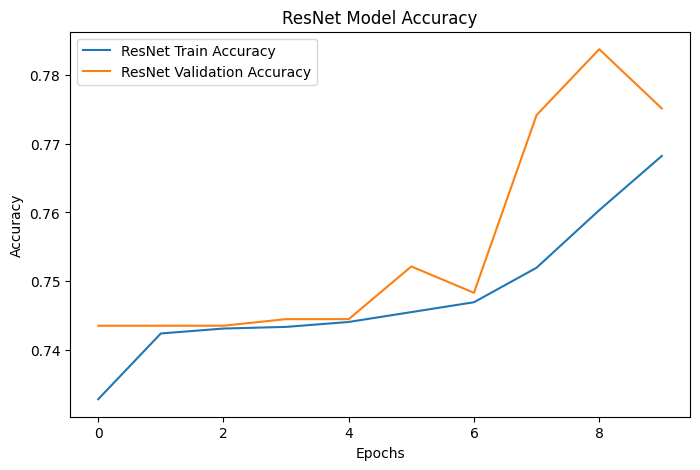

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_ResNet.history['accuracy'], label='ResNet Train Accuracy')
plt.plot(history_ResNet.history['val_accuracy'], label='ResNet Validation Accuracy')
plt.title('ResNet Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


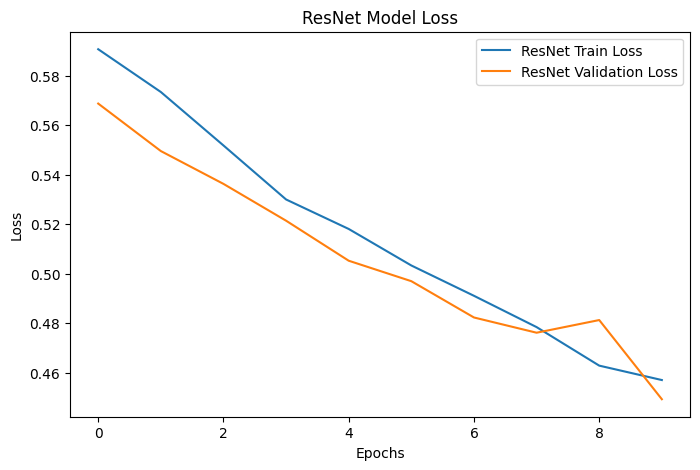

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_ResNet.history['loss'], label='ResNet Train Loss')
plt.plot(history_ResNet.history['val_loss'], label='ResNet Validation Loss')
plt.title('ResNet Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model_ResNet.save("/content/drive/MyDrive/chest_models/chest_ResNet.keras")

# Testing with Random Image

In [ ]:
img_path = "/content/drive/MyDrive/chest_xray/train/NORMAL/IM-0115-0001.jpeg"

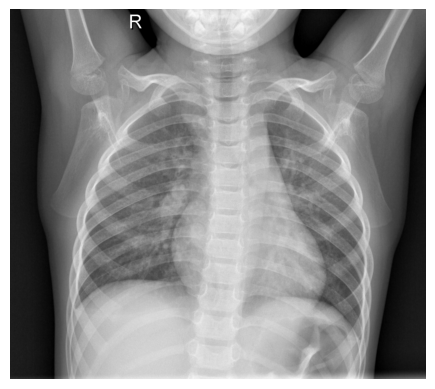

In [ ]:
import random
plt.axis('off')
plt.imshow(
    tf.keras.preprocessing.image.load_img(img_path)
)

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
img_array = img_array / 255.0  # same as rescale=1./255

In [ ]:
from tensorflow.keras.models import load_model
ResNet_loaded = load_model("/content/drive/MyDrive/chest_models/chest_ResNet.keras")

In [ ]:
prediction = ResNet_loaded.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [ ]:
if prediction[0][0]<0.5 :
  print("Normal")
else :
  print("Pneumonia")

Pneumonia


In [ ]:
prediction2 = cnn_loaded.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step


In [ ]:
if prediction2[0][0]<0.5 :
  print("Normal")
else :
  print("Pneumonia")

Normal


# Comapring the CNN and ResNet

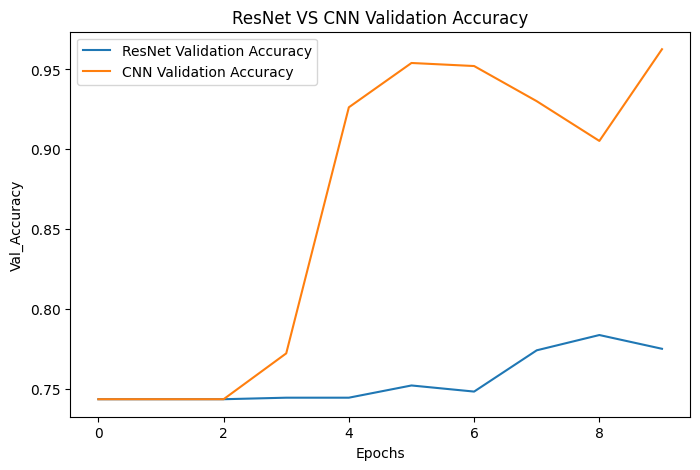

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_ResNet.history['val_accuracy'], label='ResNet Validation Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('ResNet VS CNN Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Val_Accuracy')
plt.legend()
plt.show()


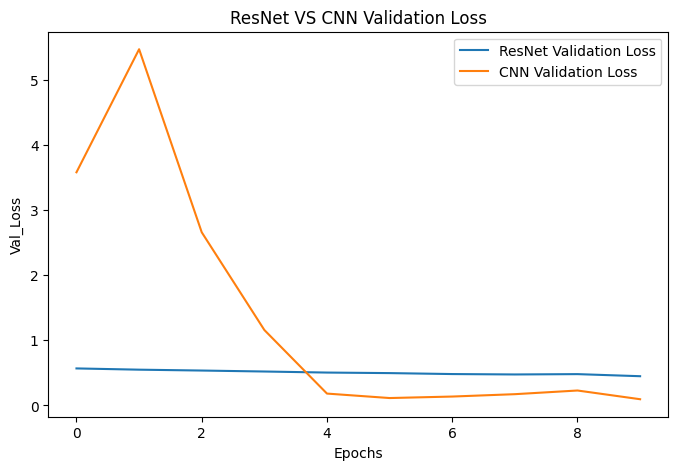

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_ResNet.history['val_loss'], label='ResNet Validation Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.title('ResNet VS CNN Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Val_Loss')
plt.legend()
plt.show()

# Using the Fine-Tuning for the "ResNet50" Model

In [ ]:
# Unfreeze last few layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile (important!)
model_ResNet.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_ResNet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 14,712,577 (56.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [ ]:
fine_tune_history = model_ResNet.fit(train_gen, epochs=10, validation_data=val_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1295s 10s/step - accuracy: 0.8308 - loss: 0.3556 - val_accuracy: 0.2565 - val_loss: 1.0434
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 124s 947ms/step - accuracy: 0.9446 - loss: 0.1514 - val_accuracy: 0.8517 - val_loss: 0.3151
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 931ms/step - accuracy: 0.9417 - loss: 0.1485 - val_accuracy: 0.9407 - val_loss: 0.1501
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 916ms/step - accuracy: 0.9450 - loss: 0.1346 - val_accuracy: 0.8565 - val_loss: 0.3305
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 928ms/step - accuracy: 0.9473 - loss: 0.1265 - val_accuracy: 0.9531 - val_loss: 0.1139
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 927ms/step - accuracy: 0.9546 - loss: 0.1273 - val_accuracy: 0.9388 - val_loss: 0.1601
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 908ms/step - accuracy: 0.9581 - loss: 0.1116 - val_accuracy: 0.8718 - val_loss: 0.3294
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 922ms/step - accuracy: 0.9641 - 

In [ ]:
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "/content/drive/MyDrive/chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_loss, test_acc = model_ResNet.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - accuracy: 0.4687 - loss: 2.0172
✅ Test Accuracy: 0.7147
✅ Test Loss: 1.0933


In [ ]:
from tensorflow.keras.models import load_model
cnn = load_model("/content/drive/MyDrive/chest_models/chest_CNN.keras")

In [ ]:
test_loss, test_acc = cnn.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step - accuracy: 0.7635 - loss: 0.6681
✅ Test Accuracy: 0.8494
✅ Test Loss: 0.4364


In [ ]:
# Unfreeze last few layers
for layer in base_model.layers[-60:]:
    layer.trainable = True

# Recompile (important!)
model_ResNet.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
fine_tune_history = model_ResNet.fit(train_gen, epochs=10, validation_data=val_gen)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.8852 - loss: 0.2687 - val_accuracy: 0.7435 - val_loss: 0.5413
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9379 - loss: 0.1568 - val_accuracy: 0.9100 - val_loss: 0.2358
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9511 - loss: 0.1343 - val_accuracy: 0.8584 - val_loss: 0.3284
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9387 - loss: 0.1516 - val_accuracy: 0.9225 - val_loss: 0.1703
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9485 - loss: 0.1304 - val_accuracy: 0.9407 - val_loss: 0.1408
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 996ms/step - accuracy: 0.9493 - loss: 0.1381 - val_accuracy: 0.9522 - val_loss: 0.1189
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9562 - loss: 0.1100 - val_accuracy: 0.9445 - val_loss: 0.1244
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9544 - loss: 0.1177 - val_a

In [ ]:
model_ResNet.save("/content/drive/MyDrive/chest_models/chest_ResNet_finetune.keras")

In [ ]:
test_loss, test_acc = model_ResNet.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 483ms/step - accuracy: 0.4625 - loss: 1.8728
✅ Test Accuracy: 0.7115
✅ Test Loss: 1.0334


# Using the MobileNet PreTrained model

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)

In [ ]:
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 4185 images belonging to 2 classes.


In [ ]:
test_gen = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
val_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1045 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

In [ ]:
mobile_net = Model(inputs=base_model.input, outputs=output)

In [ ]:
mobile_net.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobile_net.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 2,387,969 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
history_Mobilenet = mobile_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1181s 9s/step - accuracy: 0.7446 - loss: 0.5178 - val_accuracy: 0.7502 - val_loss: 0.4545
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 929ms/step - accuracy: 0.9286 - loss: 0.2047 - val_accuracy: 0.7483 - val_loss: 0.4865
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 923ms/step - accuracy: 0.9494 - loss: 0.1474 - val_accuracy: 0.7474 - val_loss: 0.5736
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 914ms/step - accuracy: 0.9589 - loss: 0.1181 - val_accuracy: 0.7464 - val_loss: 0.6517
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 912ms/step - accuracy: 0.9676 - loss: 0.1034 - val_accuracy: 0.7445 - val_loss: 0.6993
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 917ms/step - accuracy: 0.9589 - loss: 0.1079 - val_accuracy: 0.7483 - val_loss: 0.7805
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 915ms/step - accuracy: 0.9676 - loss: 0.0824 - val_accuracy: 0.7455 - val_loss: 0.7520
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 907ms/step - accuracy: 0.9707 - l

In [ ]:
test_loss, test_acc = mobile_net.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 123s 6s/step - accuracy: 0.2984 - loss: 3.0044
✅ Test Accuracy: 0.6250
✅ Test Loss: 1.6509


## MobileNetV2 finetuning

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze most layers (fine-tune last ~20)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# ==========================================================
# 5️⃣ Add Custom Head
# ==========================================================
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

mobilenet_fine = Model(inputs=base_model.input, outputs=output)

In [ ]:
mobilenet_fine.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,370,177 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [ ]:
mobilenet_fine.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobile_finetune = mobilenet_fine.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6751 - loss: 0.5765 - val_accuracy: 0.7522 - val_loss: 0.4070
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 909ms/step - accuracy: 0.9210 - loss: 0.2389 - val_accuracy: 0.7512 - val_loss: 0.4539
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 899ms/step - accuracy: 0.9491 - loss: 0.1589 - val_accuracy: 0.7665 - val_loss: 0.4488
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 907ms/step - accuracy: 0.9554 - loss: 0.1338 - val_accuracy: 0.8010 - val_loss: 0.3962
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 904ms/step - accuracy: 0.9609 - loss: 0.1212 - val_accuracy: 0.8344 - val_loss: 0.3174
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 906ms/step - accuracy: 0.9586 - loss: 0.1109 - val_accuracy: 0.8699 - val_loss: 0.2572
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 907ms/step - accuracy: 0.9609 - loss: 0.1039 - val_accuracy: 0.9129 - val_loss: 0.1718
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 907ms/step - accuracy: 0.9681 - lo

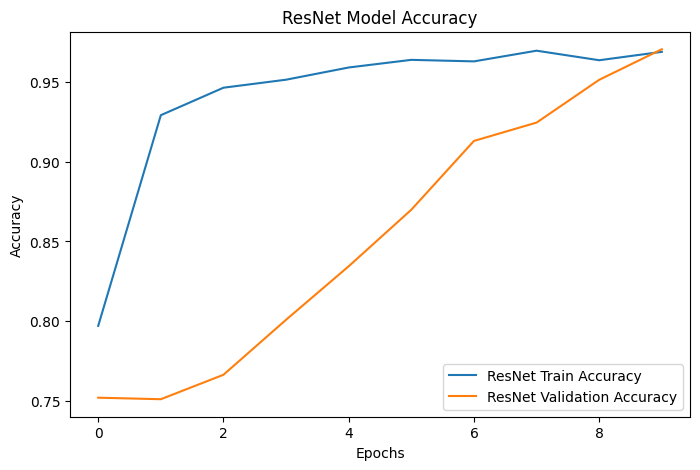

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_mobile_finetune.history['accuracy'], label='ResNet Train Accuracy')
plt.plot(history_mobile_finetune.history['val_accuracy'], label='ResNet Validation Accuracy')
plt.title('ResNet Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
test_loss, test_acc = mobilenet_fine.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 503ms/step - accuracy: 0.5673 - loss: 1.1641

✅ Test Accuracy: 0.7644
✅ Test Loss: 0.6503


In [ ]:
mobile_net.save("/content/drive/MyDrive/chest_models/chest_mobilenet.keras")

In [ ]:
mobilenet_fine.save("/content/drive/MyDrive/chest_models/chest_mobilenet_fine.keras")

# MobileNet FineTuning2

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=False,   # keep False for chest X-rays!
    fill_mode='nearest',
    validation_split=0.2
)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 4185 images belonging to 2 classes.


In [ ]:
test_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 500 images belonging to 2 classes.


In [ ]:
val_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1045 images belonging to 2 classes.


In [ ]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

In [ ]:
from tensorflow.keras.models import Model

In [ ]:
mobilenet_fine2 = Model(inputs=base_model.input, outputs=output)

In [ ]:
mobilenet_fine2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobile_finetune2 = mobilenet_fine2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3635s 28s/step - accuracy: 0.6735 - loss: 0.5989 - val_accuracy: 0.7627 - val_loss: 0.3816
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8663 - loss: 0.3099 - val_accuracy: 0.7608 - val_loss: 0.4306
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9050 - loss: 0.2481 - val_accuracy: 0.7703 - val_loss: 0.4599
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9275 - loss: 0.1899 - val_accuracy: 0.8057 - val_loss: 0.4169
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9298 - loss: 0.1779 - val_accuracy: 0.8316 - val_loss: 0.3573
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9363 - loss: 0.1662 - val_accuracy: 0.8612 - val_loss: 0.3003
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9429 - loss: 0.1513 - val_accuracy: 0.9177 - val_loss: 0.2005
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9422 - loss: 0.1529 - val_ac

In [ ]:
test_loss, test_acc = mobilenet_fine2.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 329s 21s/step - accuracy: 0.7629 - loss: 0.7250

✅ Test Accuracy: 0.7540
✅ Test Loss: 0.7503


In [ ]:
mobilenet_fine2.save("/content/drive/MyDrive/chest_models/chest_mobilenet_fine2.keras")